### Google Capstone - Exploratory Data Analysis & Data Preprocessing

##### Scenario

You are a data professional working for Salifort Motors. Currently, there is a high rate of turnover among Salifort employees. (Note: In this context, turnover data includes both employees who choose to quit their job and employees who are let go). Salifort’s senior leadership team is concerned about how many employees are leaving the company. Salifort strives to create a corporate culture that supports employee success and professional development. Further, the high turnover rate is costly in the financial sense. Salifort makes a big investment in recruiting, training, and upskilling its employees. 

If Salifort could predict whether an employee will leave the company, and discover the reasons behind their departure, they could better understand the problem and develop a solution. 

As a first step, the leadership team asks Human Resources to survey a sample of employees to learn more about what might be driving turnover.  

Next, the leadership team asks you to analyze the survey data and come up with ideas for how to increase employee retention. To help with this, they suggest you design a model that predicts whether an employee will leave the company based on their job title, department, number of projects, average monthly hours, and any other relevant data points. A good model will help the company increase retention and job satisfaction for current employees, and save money and time training new employees. 

As a specialist in data analysis, the leadership team leaves it up to you to choose an approach for building the most effective model to predict employee departure.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MinMaxScaler

# Import data
df = pd.read_csv("HR_GC_Dataset.csv")
df.columns = (df.columns.str.lower()) # Make all column names lowercase for consistency.

In [2]:
# View how many columns and rows of data and the first 3 rows.
print(f"Rows {df.shape[0]}, Columns: {df.shape[1]}")
df.head(3)

Rows 14999, Columns: 10


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium


<div style="text-align: left; display: inline-block;">
    
| Column name            | Type  | Description                                      |
|------------------------|-------|--------------------------------------------------|
| satisfaction_level     | int64 | The employee’s self-reported satisfaction level [0-1] |
| last_evaluation        | int64 | Score of employee's last performance review [0–1] |
| number_project         | int64 | Number of projects employee contributes to       |
| average_monthly_hours  | int64 | Average number of hours employee worked per month |
| time_spend_company     | int64 | How long the employee has been with the company (years) |
| work_accident          | int64 | Whether or not the employee experienced an accident while at work |
| left                   | int64 | Whether or not the employee left the company     |
| promotion_last_5years  | int64 | Whether or not the employee was promoted in the last 5 years |
| department             | str   | The employee's department                        |
| salary                 | str   | The employee's salary (low, medium, or high)     |

</div>

#### Data Cleaning

Check for outliers, duplicates and NA values.

In [3]:
# Firstly check for duplicates.
print("Duplicate entries:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("The 3,008 duplicates have now been removed.")

Duplicate entries: 3008
The 3,008 duplicates have now been removed.


In [4]:
# Check for null values.
df.info()
print("No null values, so no further action required.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11991 entries, 0 to 11990
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 936.9+ KB
No null values, so no further action required.


In [5]:
# Check for outliers by looking the descriptive statistics.
df.describe().loc[['min', 'mean', 'max']]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Nothing out of the ordinary in the decriptive statistics, with no exceptionally high or low outliers detected. The highest tenure is 10 years, which is not unusual, but is triple the mean, so I will create a boxplot to visualise the spread of employee tenure.

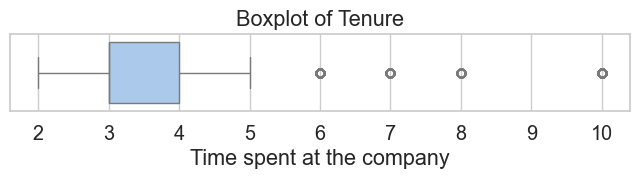

In [6]:
# Plot a boxplot of the tenure of the employees
sns.set_theme(style="whitegrid", palette="pastel", font_scale=1.3)  
plt.figure(figsize=(8, 1))
sns.boxplot(data=df, x='time_spend_company')
plt.title('Boxplot of Tenure')
plt.xlabel('Time spent at the company')
plt.show()

In [7]:
# Show the counts of each tenure length.
df["time_spend_company"].value_counts()

time_spend_company
3     5190
2     2910
4     2005
5     1062
6      542
10     107
7       94
8       81
Name: count, dtype: int64

There are almost 1,000 individuals in the outlier range of 6+ years of service to the company. Some models do not handle outliers as well, such as logistic regression, but they will be kept in the dataset, as they are not anomalous.

#### Exploratory Data Analysis

In [8]:
# Look at the decriptive statistics about the data.
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


The average employee works 200 hours a month. This is 46 hours a week, much higher than the norm of 37.5.

The average employee has four projects and has a last evaluation of 72%, double the minimum of 36%.

In [9]:
# left is the target variable in this dataset. Calculating the percentage breakdown of each of the two classes.
left_counts = df.left.value_counts().tolist() # Get left column counts and convert to list.
total = sum(left_counts)
print(f"Total rows: {total}")
print(f"Didn't leave: {left_counts[0]/total*100:.2f}%")
print(f"Did leave: {left_counts[1]/total*100:.2f}%")
df.left.value_counts() # Count the number of each value in a column.

Total rows: 11991
Didn't leave: 83.40%
Did leave: 16.60%


left
0    10000
1     1991
Name: count, dtype: int64

16.6% of employees left the company. This does give us an unbalanced dataset, but not to an extreme level where undersampling or oversampling would need to be used to compensate for the imbalance.

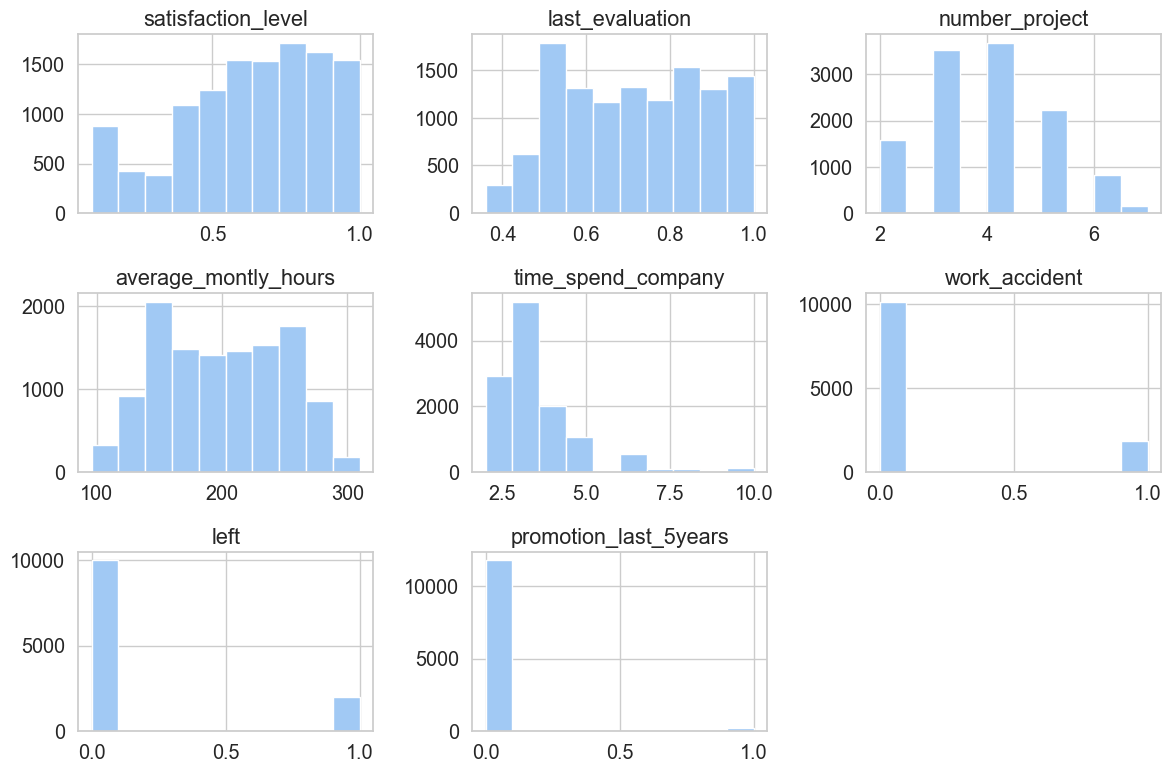

In [10]:
# Plot histograms of each columns data.
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

**Satisfaction level:** The is a right skewed distribution for the most part, with a spike on the left for a high number of very disatisfied employees.

**Last Evaluation:** A right skewed distribution, with a high number of scores around 0.5.

**Number Project:** This has a fairly normal distribution, with most employees having done 3 or 4 project, with some a few hundred doing 7, and no one doing less than 2.

**Average Monthly Hours:** A bimodal distribution with peaks at 150 and 250. The larget count is at 150, which divided by 4 would give 37.5 hours a week, very common working hours. At the right tail of the distribution there are handfuls of workers who claim to be working almost 16 hour days, at around 300 monthly hours.

**Time Spent Company:** A left skewed distribution with the majority of employees having been at the company for four years or less, with over half being there for three years or less. A few hundred in the 8-10 year range, showing the company has been around for a while, but most people do not stay for more than three or four years. Very normal in todays job market where on average employees work for comapnies for between 3 and 5 years.

**Work Accident, Left, Promotion:** All binomial distibutions with the vast majority being 0. Which is good in the case of work accidents. It is worrying however that about 1 in 6 employees has had a work accident. Just 203 employees have been promoted in the last 5 years, under 2%. It would be interesteing to see if any of those few promoted employees left.

In [11]:
# Count number of rows where promoted_last_5years and left are both 1.
p_and_l = ((df['promotion_last_5years'] == 1) & (df['left'] == 1)).sum()
print("Promoted and left company:", p_and_l)
print(f"As a percentage of the 203: {p_and_l/203*100:.2f}%")

Promoted and left company: 8
As a percentage of the 203: 3.94%


Only 8 out of the 203 employees that were promoted left the company. This is just 4%, four times lower than the overall 16% of employees that left the company. So, by promoting an empoyee, you greatly reduce the chance that they will leave the company.

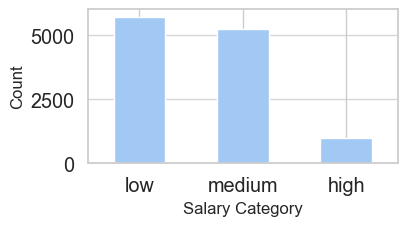

In [12]:
# Plot a bar chart of the salary column counts.
salary_counts = df['salary'].value_counts() # Get salary column counts.
salary_counts.plot(kind='bar', figsize=(4, 2))
plt.xlabel('Salary Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.8)
plt.show()

In [13]:
sal_counts = df['salary'].value_counts().tolist()
sal_cat = ["Low", "Medium", "High"]
for ind, i in enumerate(sal_counts):
    print(sal_cat[ind], f": {i/total*100:.2f}%")

Low : 47.87%
Medium : 43.87%
High : 8.26%


About half of the employees have a low wage, with 44% having a medium wage, and just 8% a high wage. This may be an important attribute when predicting employee attrition, as high wage workers are generally less likely to leave a company than lower paid ones.

In [14]:
dep_counts = df['department'].value_counts().tolist()
dep_cat = ["Sales", "Technical", "Support", "IT", "Product_mng", "Marketing", "RandD", "Accounting", "HR", "Management"]
for ind, i in enumerate(dep_counts):
    print(dep_cat[ind], f": {i/total*100:.2f}%")

Sales : 27.01%
Technical : 18.71%
Support : 15.19%
IT : 8.14%
Product_mng : 5.79%
Marketing : 5.72%
RandD : 5.61%
Accounting : 5.18%
HR : 5.01%
Management : 3.64%


The largest department category is sales with 27%, then technical and support. The other departments are far smaller, with management making up under 4% of employees. Accounting, HR and R&D come in round 5%. I am interested to see if there is a correlation between department and salary, so will run a chi-squared test.

###### Chi-Squared Test

A tess to determine if two categorical variables are independant.

Null Hypothesis: The two variables are independent and have no relationship with each other.

Alternative Hypothesis: The two variables are dependent, soa relationship exists between them.

With 3 rows and 10 columns it will have 18 degrees of freedom [DoF = (r-1) x (c-1)].

If the resulting p-value is below 0.05, then the null hypotheis can be rejected.

In [15]:
# Create a two-way frequency table to visualise salaries by department.
frequency = pd.crosstab(df['salary'], df['department'])
print("Two-way Frequency Table")
display(frequency.rename(columns=lambda x: str(x)[:6]+"..."))

# Display the table with percentages for better visual analysis.
frequency.loc['Total']= frequency.sum()
percentages = frequency.apply(lambda x: x / x.loc['Total'] * 100)
percentages = percentages.drop('Total') # Drop Total row for both versions.
frequency = frequency.drop('Total')
print("Two-way Frequency Table - Percentages")
display(percentages.rename(columns=lambda x: str(x)[:6] + "...").round(2))

Chi2ContingencyResult = chi2_contingency(frequency)
print("P-value:", Chi2ContingencyResult[1])

Two-way Frequency Table


department,IT...,RandD...,accoun...,hr...,manage...,market...,produc...,sales...,suppor...,techni...
salary,,,,,,,,,,
high,71,47,63,38,128,62,52,237,126,166
low,476,322,296,296,139,310,343,1553,867,1138
medium,429,325,262,267,169,301,291,1449,828,940


Two-way Frequency Table - Percentages


department,IT...,RandD...,accoun...,hr...,manage...,market...,produc...,sales...,suppor...,techni...
salary,,,,,,,,,,
high,7.27,6.77,10.14,6.32,29.36,9.21,7.58,7.32,6.92,7.40
low,48.77,46.40,47.67,49.25,31.88,46.06,50.00,47.95,47.61,50.71
medium,43.95,46.83,42.19,44.43,38.76,44.73,42.42,44.74,45.47,41.89


P-value: 2.693230675813006e-51


By looking at the percentage table, the management department immediatly springs out as being much better paid than any other one, with 29% being highly paid. The other departments are much more equal, with only accounting and marketing having 9-10% of employees being highly paid, compared to the other departments at 6-7.5%.

As the p-value is well under 0.05 we can reject the null hypthesis and conclude that salary and department are not independant.

##### Look at the correlations between the variables using a scatter plot matrix and heatmap

This will visualise any correlations between variables, to give us a deeper insight into the data.

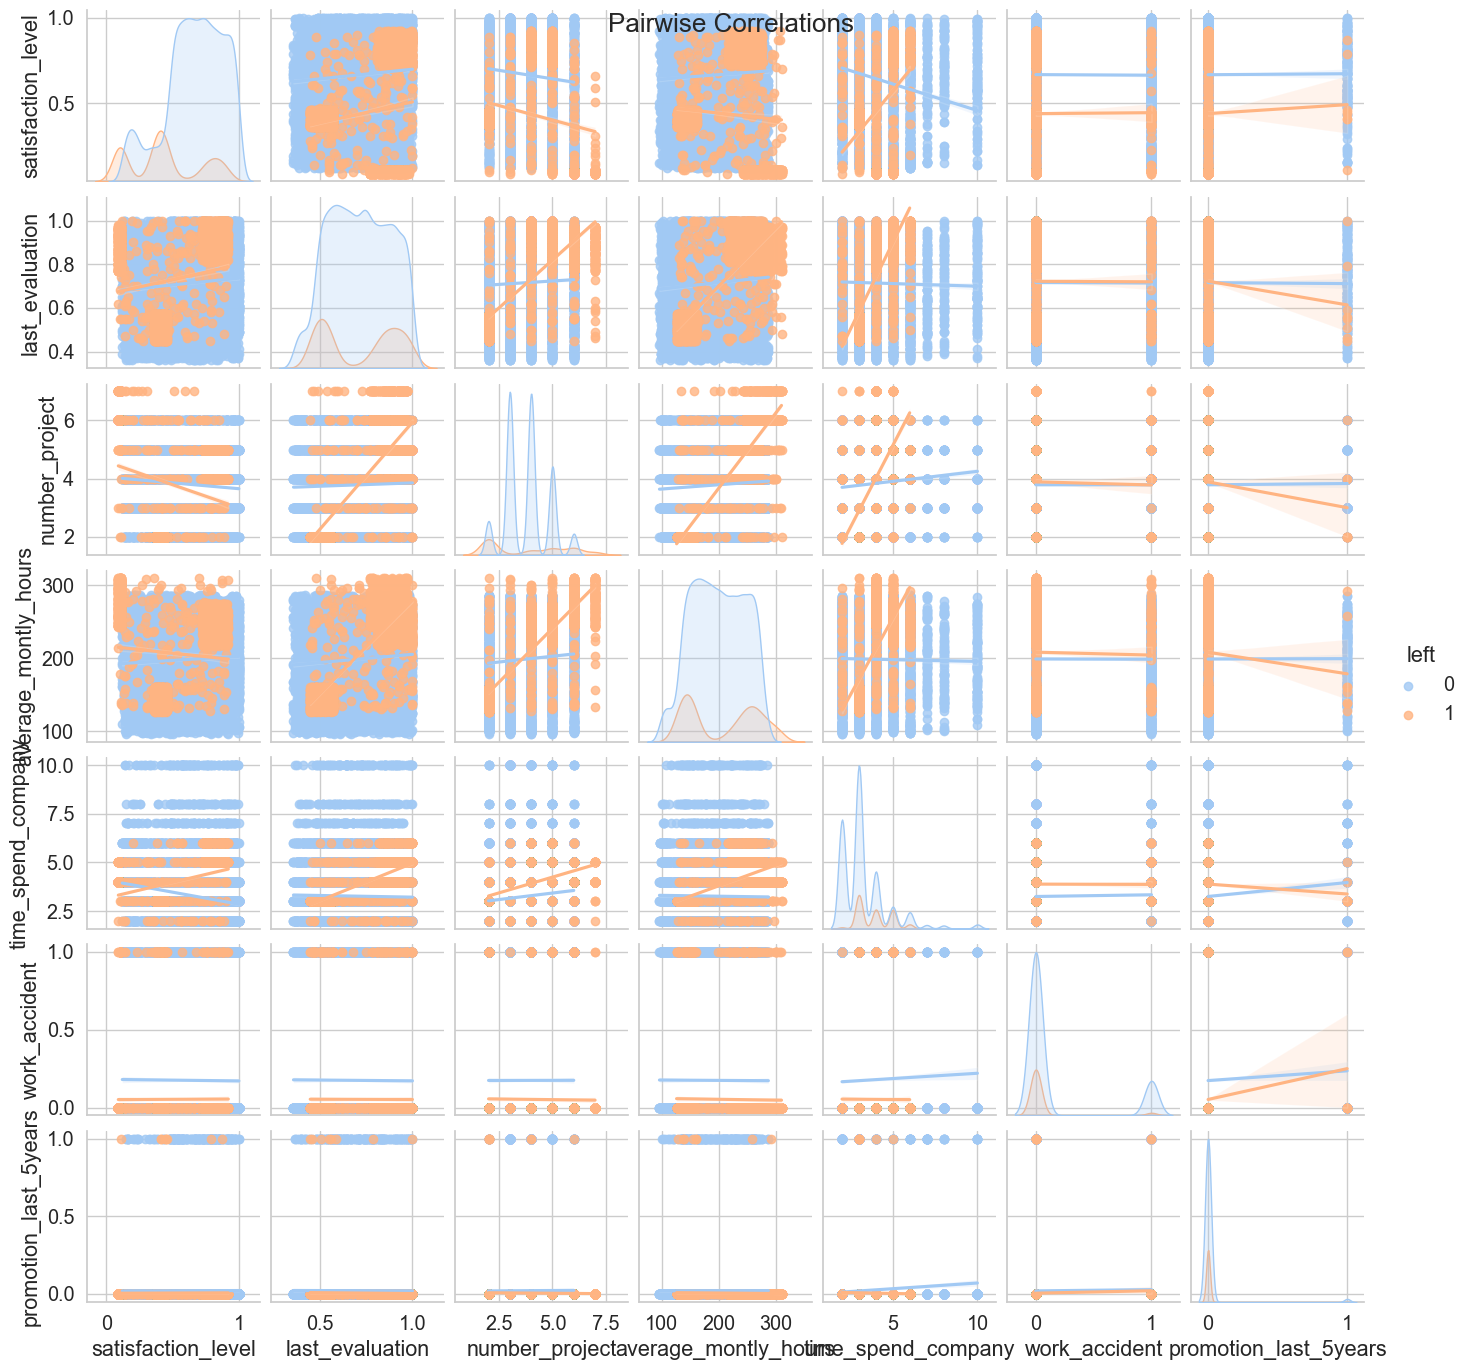

In [16]:
# Create pairplot to view pairwise correlations.
pairwise_plots = sns.pairplot(df, kind="reg", height=2.0, hue="left")
pairwise_plots.figure.suptitle("Pairwise Correlations")
plt.style.use("seaborn-v0_8-whitegrid")
plt.show()

Some insights can be drawn from this evaluation:

1) Looking at the time spent at the company column, there are few people that left after 6 years, showing a loyalty after a certain point.

2) There is a postive correlations between number of projects and average monthly hours. This skews higher for people who then left, perhaps because they are overworked.

3) There is a postive correlations between number of projects and average monthly hours for both people that left and those that didn't.

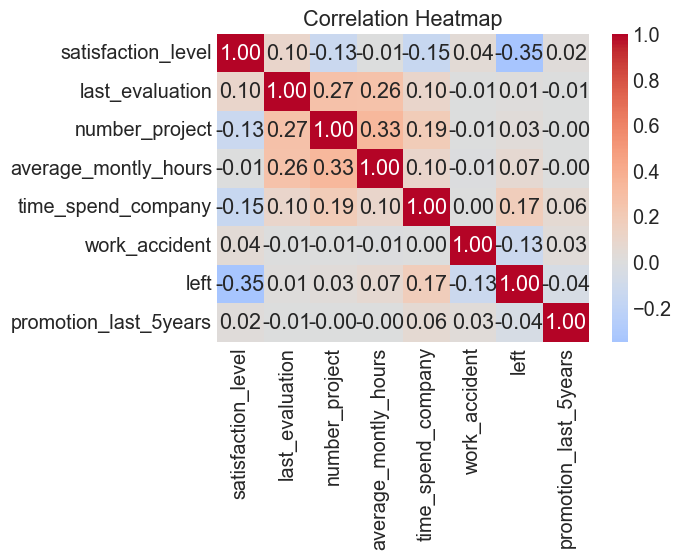

In [17]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows much of the same as the pairplots, with the strong postive correlation between number of projects and monthly hours, and also time spent at company.

A new insight is that satisfaction level is negatively correlated with left. This makes sense, as the more satisfied the employee is, the less likely they would be likely to leave.

Interestingly the longer the person works at the company, and the more projects they do, the less they themselves are satisfied, even if their boss is happy with them for doing more projects, show by the negative correlations between satisfaction and projects and also time spent at company.

The last evaluation is positively correlated with average monthly hours and number of projects. This makes sense, that hard workers who do more hours and projects are judged to be doing well compared to their peers. I will investigate this further by creating a scatterplot of monthly hours by last evaluation score to see if there is an insight to be gained regarding the employees who left the company.

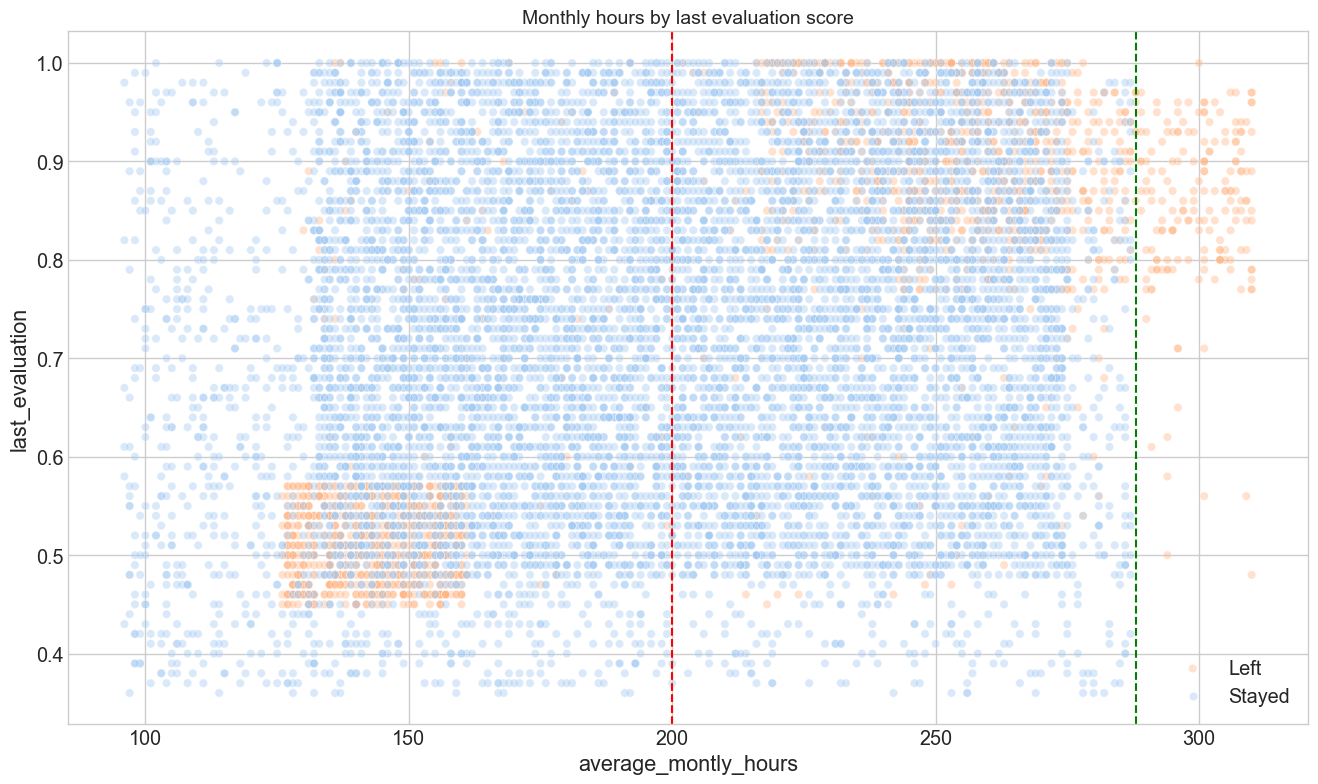

In [18]:
# Create scatterplot of average_montly_hours versus last_evaluation
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df, x='average_montly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=200, color='red', label='200 hrs/mo', ls='--')
plt.axvline(x=288, color='green', label='285 hrs/mo', ls='--')
plt.legend(labels=['Left', 'Stayed'], loc='lower right')
plt.title('Monthly hours by last evaluation score', fontsize='14');

The scatterplot shows there are two main clusters of employees who left the company:
* Employees who worked 160 hours or less and also performed poorly in thier evaluations. These employees were perhaps not that interested in thier work anymore, hence putting a low amount of effort and leaving the company.
* Employees who were high performing and also worked a high number of hours. For these employees career progression may have been a driving factor, as the are high performing, hard working individuals.

Additionaly, all employees who worked over 288 hours a month on average left the company. This could be becuase of burnout, or becuase they moved to a better job. This could be investigated further with more information such as thier exit interviews.

#### Feature Engineering

One hot encoding: This will be done with the salary and department variables to enable them to be used by machine learning models.

Normalising: This will be done with the MinMax scaler to scale certain variables between 0 and 1 to work better with certain classifiers and models.

In [19]:
# One-Hot Encoded Features: Salary and Department
df = df.join(pd.get_dummies(df["salary"])) # One-hot code the three answers and join to the dataframe.
df = df.drop("salary", axis=1) # Drop original column.
df = df.join(pd.get_dummies(df["department"])) # One-hot code the three answers and join to the dataframe.
df = df.drop("department", axis=1) # Drop original column.

# Convert all of the one-hot encoded features that are True or False by default to 0 or 1.
df = df.map(lambda x: 1 if x == True else 0 if x == False else x)

In [20]:
# Apply Minmax scaling to ensure data values sit bewteen 0 and 1.
scaler = MinMaxScaler()
df['number_project'] = scaler.fit_transform(df[['number_project']])
df['average_montly_hours'] = scaler.fit_transform(df[['average_montly_hours']])
df['time_spend_company'] = scaler.fit_transform(df[['time_spend_company']])

In [21]:
# View data after changes have been made.
display(df.head().rename(columns=lambda x: str(x)[:6] + "...").round(2))

,satisf...,last_e...,number...,averag...,time_s...,work_a...,left...,promot...,high...,low...,...,IT...,RandD...,accoun...,hr...,manage...,market...,produc...,sales...,suppor...,techni...
0,0.38,0.53,0.0,0.29,0.12,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,0.6,0.78,0.50,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,1.0,0.82,0.25,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,0.6,0.59,0.38,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,0.0,0.29,0.12,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [22]:
# Export data
df.to_csv('preproccessed_data_Google_capstone.csv',index=False)